In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcYnJ1bm9cRG9jdW1lbnRzXFNhdG9zaGlEaWNlRGF0YUFuYWx5c2lz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\importlib\\_bootstrap.py": 1771155014.293536, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\importlib\\_bootstrap_external.py": 1771155014.2945347, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\zipimport.py": 1771155014.1963546, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\codecs.py": 1771155014.1591544, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\aliases.py": 1771155014.2269495, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\_win_cp_codecs.py": 1771155014.265126, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\__init__.py": 1771155014.2656302, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\utf_8.py": 1771155014.2641263, "C:\\Users\\bruno\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\cp1252.py": 1771155014.232

In [2]:
import pandas

pandas.set_option('display.max_columns', None)
pandas.set_option('display.width', None)
pandas.set_option('display.max_colwidth', None)

def read_dataset(name, columns):
    return pandas.read_csv(f"./data/raw/{name}", header=None, engine='pyarrow', names=columns)

def save_parquet(dataframe: pandas.DataFrame, name):
    return dataframe.to_parquet(f"./data/processed/{name}.parquet", index=False)

def read_parquet(name, columns=None):
    return pandas.read_parquet(f"./data/processed/{name}.parquet", columns=columns)

In [3]:
from src.data_loading.data_loader import read_dataset

transactions = read_dataset("transactions.csv", ["timestamp", "transaction_block_id", "transaction_id", "is_codebase", "transaction_fee"])

duplicated = transactions.duplicated(subset=["transaction_id"], keep=False)

invalid_transactions = transactions[duplicated].sort_values("transaction_id")

print(invalid_transactions)

         timestamp  transaction_block_id  transaction_id  is_codebase  \
142572  1289723848                 91722          142572            1   
142841  1289781379                 91880          142572            1   
142726  1289757588                 91812          142726            1   
142783  1289768691                 91842          142726            1   

        transaction_fee  
142572                0  
142841                0  
142726                0  
142783                0  


In [4]:
from src.data_loading.data_loader import read_dataset

outputs = read_dataset("outputs.csv", ["transaction_id", "output_position", "output_address_id", "amount", "script_type"])

duplicated = outputs.duplicated(subset=["transaction_id", "output_position"], keep=False)

invalid_outputs = outputs[duplicated].sort_values("transaction_id")

print(invalid_outputs)

        transaction_id  output_position  output_address_id      amount  \
172980          142572                0             141029  5000000000   
173305          142572                0             141029  5000000000   
173166          142726                0             141187  5000000000   
173237          142726                0             141187  5000000000   

        script_type  
172980            1  
173305            1  
173166            1  
173237            1  


In [5]:
import pandas
from src.data_loading.data_loader import read_dataset, save_parquet

inputs = read_dataset("inputs.csv", ["transaction_id", "input_transaction_id", "input_transaction_position"])

outputs = read_dataset("outputs.csv", ["transaction_id", "output_position", "output_address_id", "amount", "script_type"])
outputs = outputs.drop(columns=["script_type"])
invalid_outputs = outputs.duplicated(subset=["transaction_id", "output_position"], keep=False)
outputs = outputs[~invalid_outputs]

transactions = read_dataset("transactions.csv", ["timestamp", "transaction_block_id", "transaction_id", "is_codebase", "transaction_fee"])
transactions = transactions.drop(columns=["is_codebase"])
invalid_transactions = transactions.duplicated(subset=["transaction_id"], keep=False)
transactions = transactions[~invalid_transactions]
transactions["timestamp"] = pandas.to_datetime(transactions["timestamp"], unit="s")

complete_transactions = transactions.merge(inputs, how="left").merge(outputs, how="left")

mappings = read_dataset("mappings.csv", ["address_hash", "address_id"])
save_parquet(mappings, "mappings")

satoshi_dices = pandas.read_csv("./data/raw/satoshiDiceInfos.tsv", sep='\t')[["Name", "Address"]]
satoshi_dices.columns = ["name", "address_hash"]
satoshi_dices = satoshi_dices.merge(mappings)

complete_transactions["is_satoshi_bet"] = complete_transactions["output_address_id"].isin(satoshi_dices["address_id"])

save_parquet(complete_transactions, "transactions")
save_parquet(satoshi_dices, "satoshi_dices")

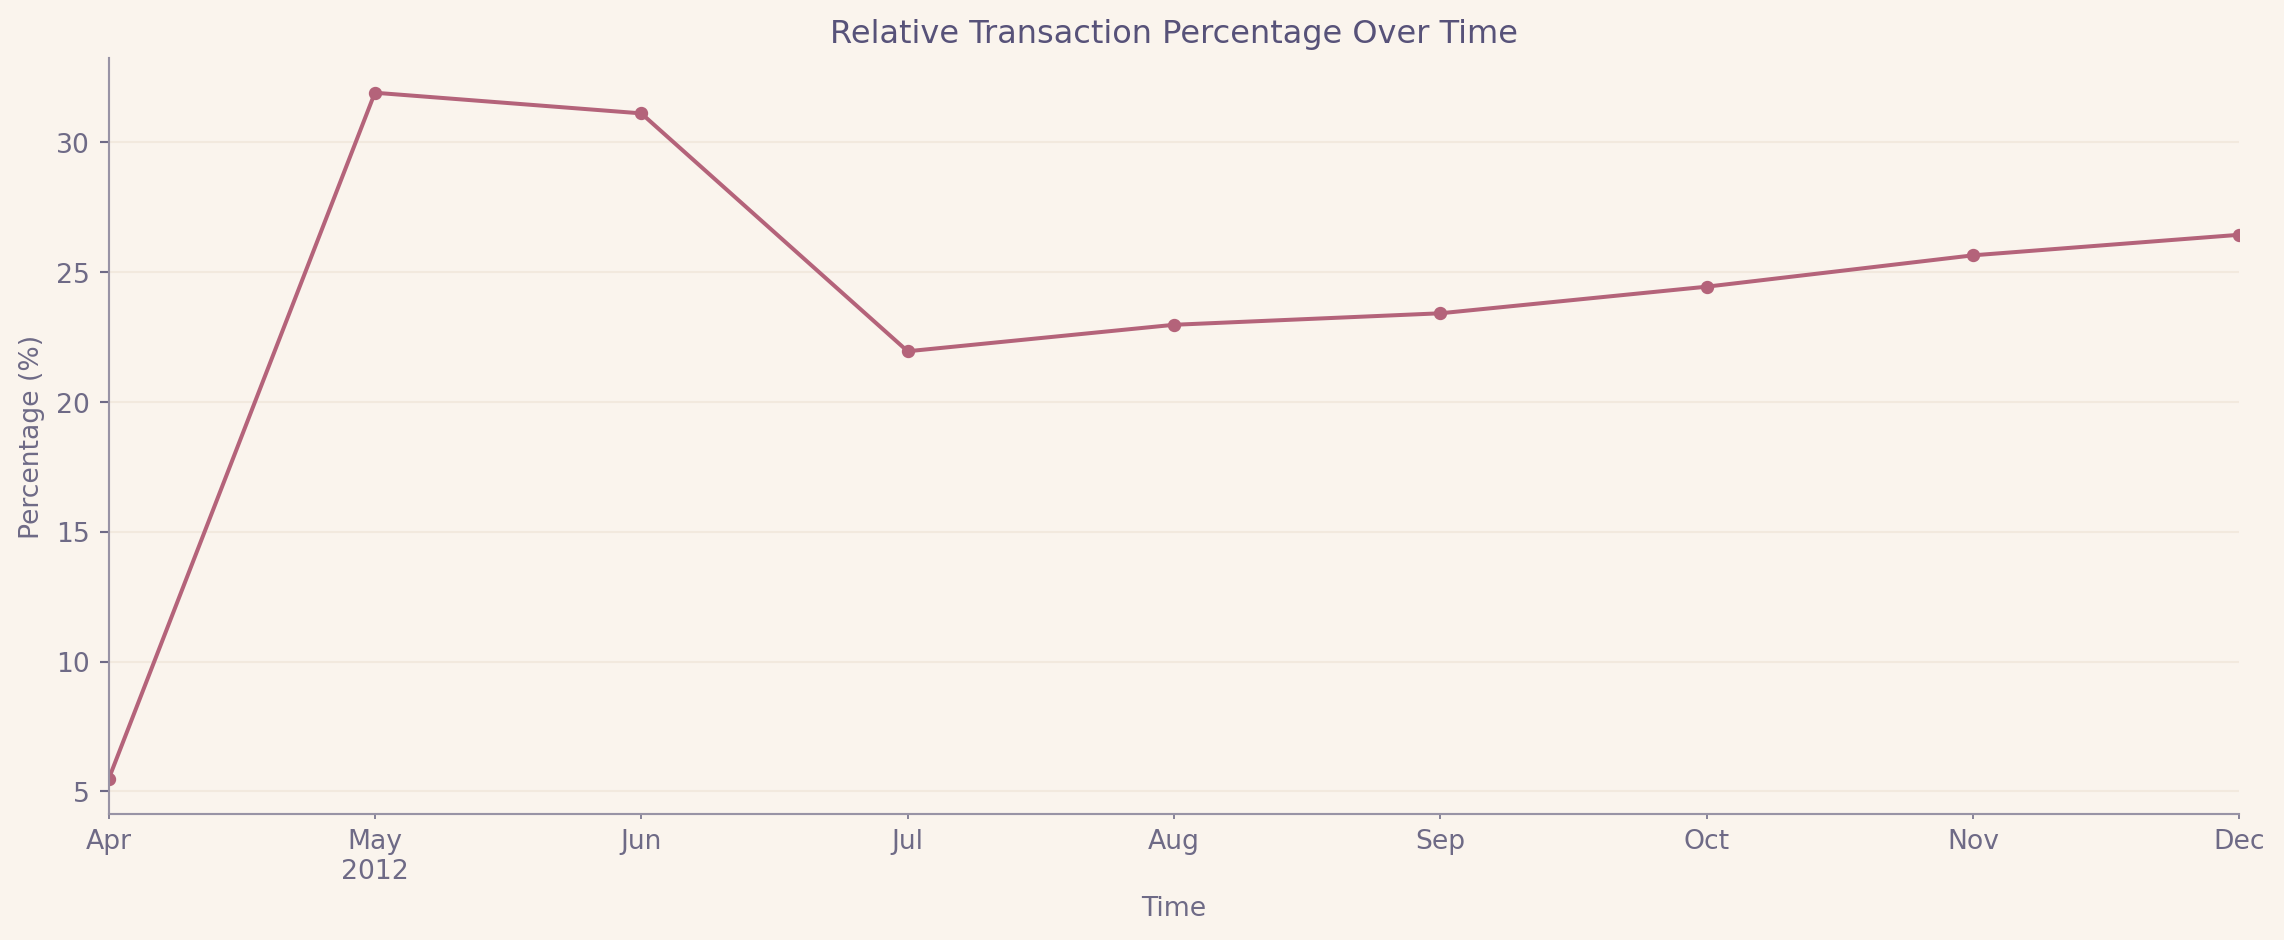

<Figure size 672x480 with 0 Axes>

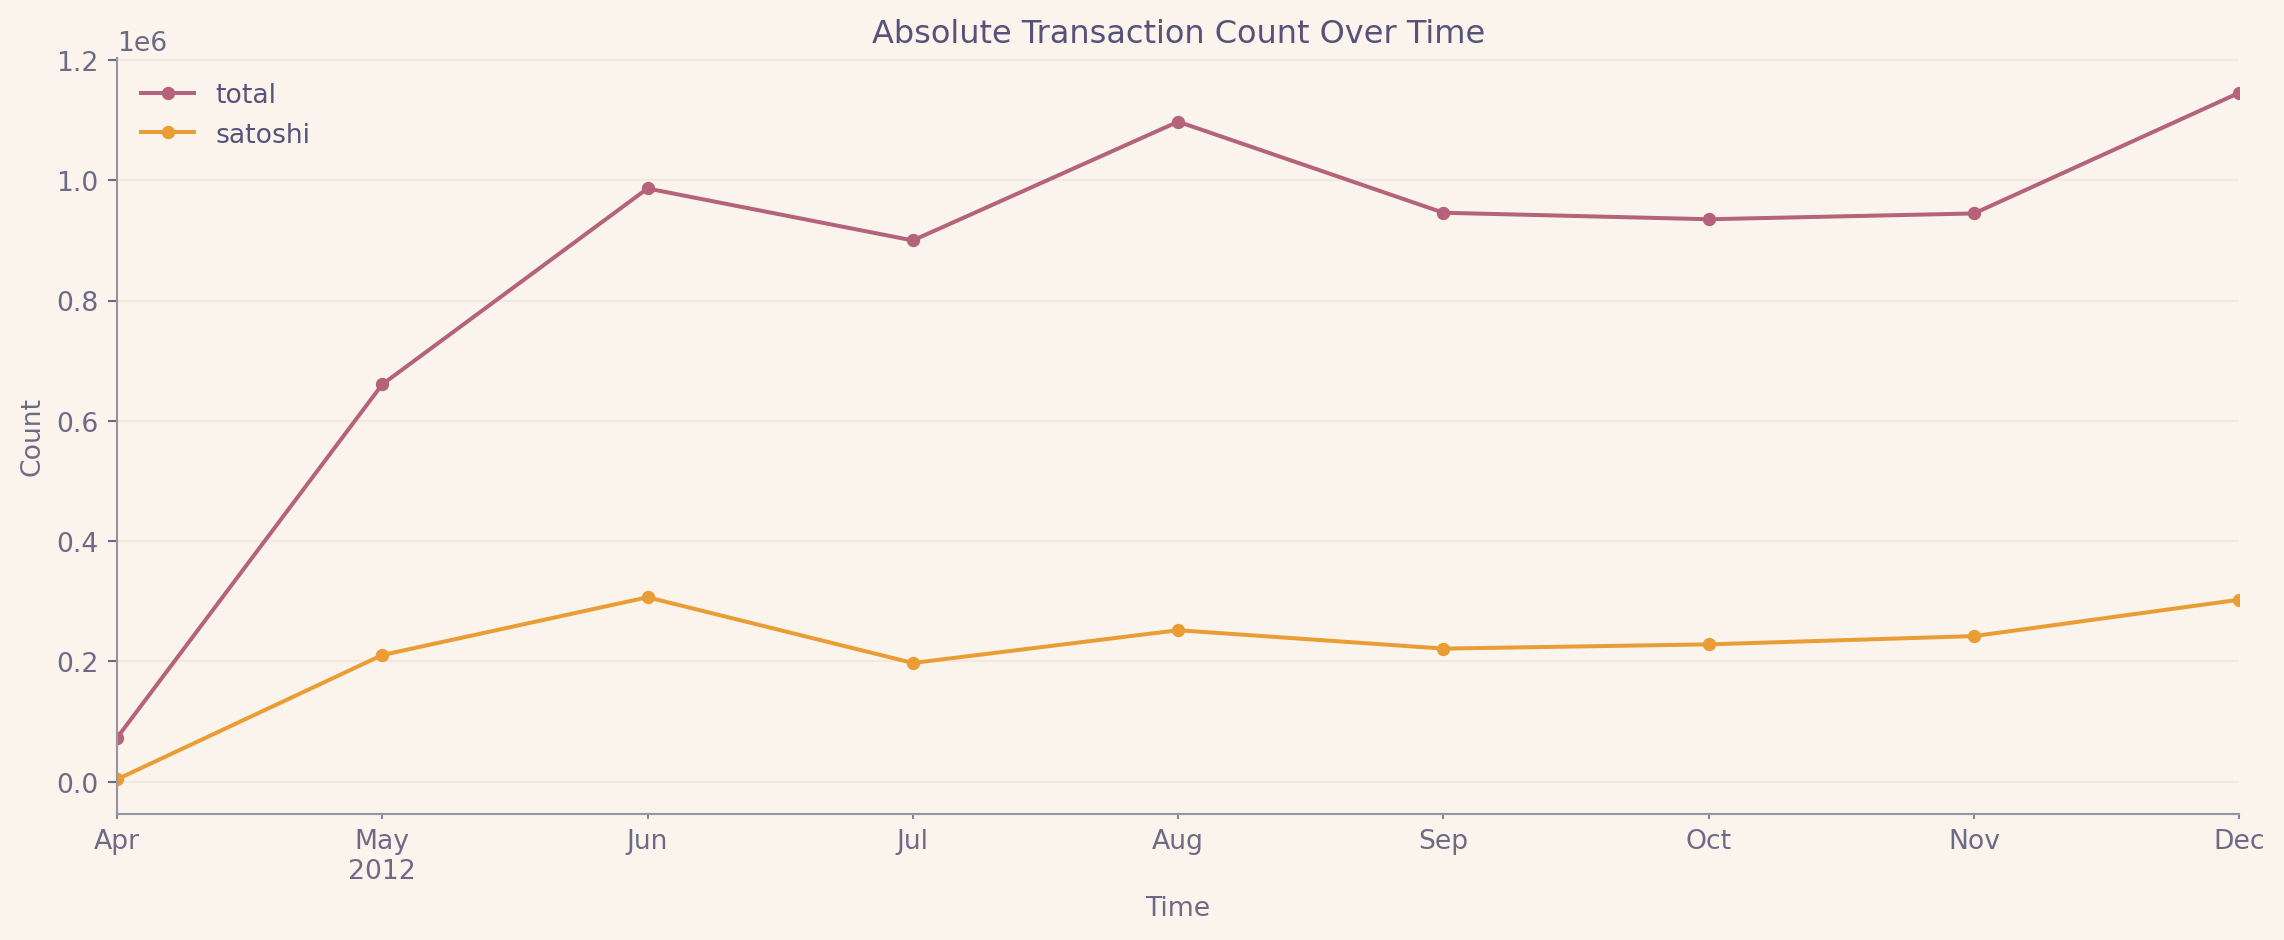

<Figure size 672x480 with 0 Axes>

In [6]:
import pandas
from src.plotting.plots import plot_absolute_transaction_percentage, plot_relative_transaction_percentage
from src.data_loading.data_loader import read_parquet

transactions = read_parquet("transactions", columns=["timestamp", "is_satoshi_bet", "amount", "transaction_id"])
satoshi_bets = transactions[transactions["is_satoshi_bet"]]

earliest_satoshi_bet_timestamp = satoshi_bets["timestamp"].min()

def resample(dataframe, start, time_step="1ME"):
	return dataframe[dataframe["timestamp"].between(start, "2023-12-31")].resample(time_step, on="timestamp")

def resampled_amount(dataframe, start):
	return resample(dataframe, start)["transaction_id"].nunique()

transactions_amount = resampled_amount(transactions, earliest_satoshi_bet_timestamp)
satoshi_bets_amount = resampled_amount(satoshi_bets, earliest_satoshi_bet_timestamp)

transactions_amount.name = None
satoshi_bets_amount.name = None

relative_amounts = (satoshi_bets_amount / transactions_amount * 100)

plot_relative_transaction_percentage(relative_amounts)

absolute_amounts = pandas.DataFrame({
    "total": transactions_amount,
    "satoshi": satoshi_bets_amount
})

plot_absolute_transaction_percentage(absolute_amounts)

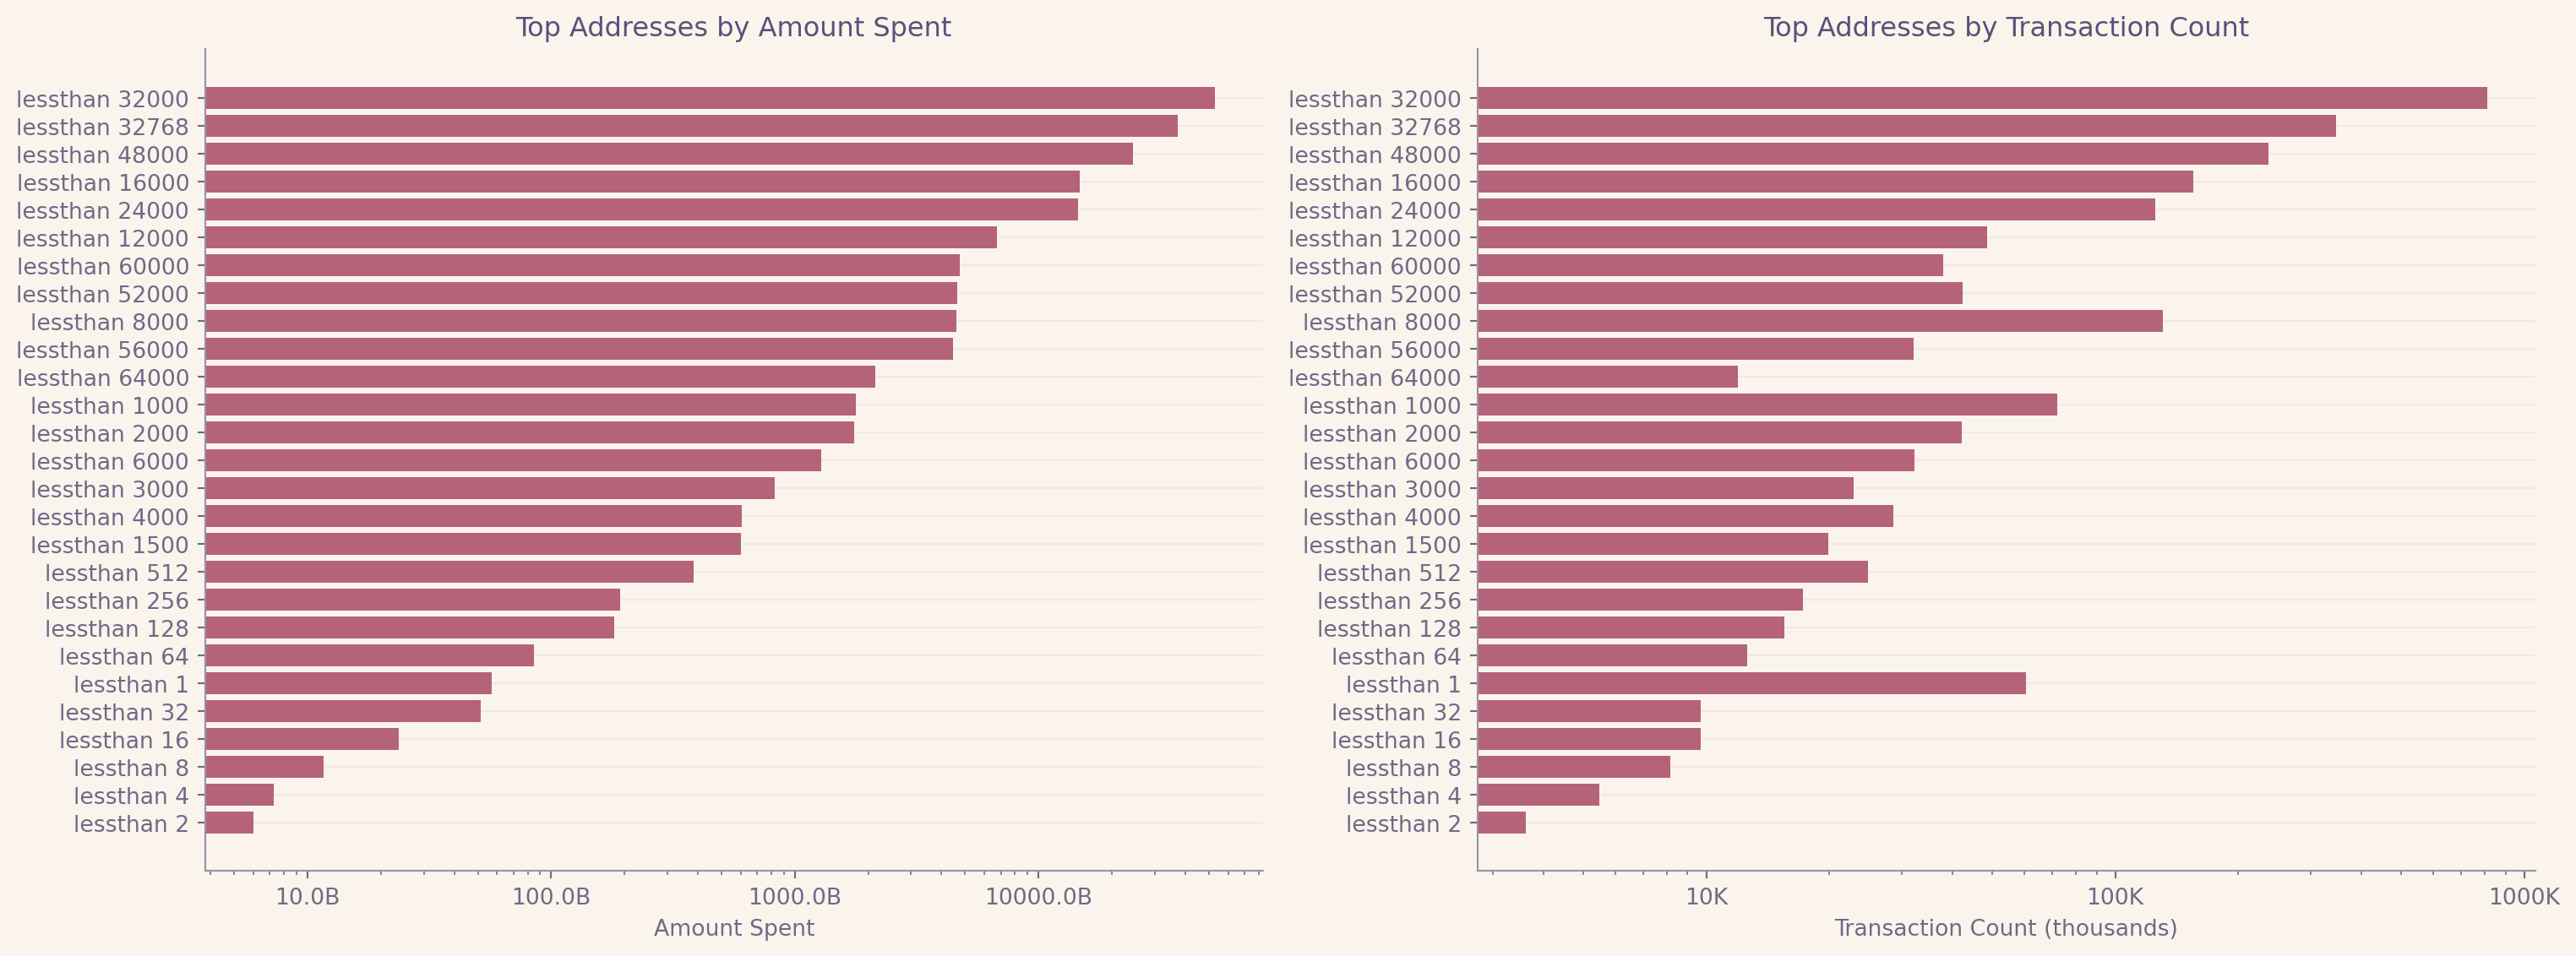

<Figure size 672x480 with 0 Axes>

In [7]:
from src.plotting.plots import plot_satoshi_dice_popularity
from src.data_loading.data_loader import read_parquet
from src.data_loading.satoshi_dices_info import name, address_hash

transactions = read_parquet("transactions", columns=["is_satoshi_bet", "amount", "transaction_id", "output_address_id", "output_position"])
satoshi_bets = transactions[transactions["is_satoshi_bet"]]

satoshi_outputs = satoshi_bets.drop_duplicates(subset=["transaction_id", "output_address_id", "output_position"])[["output_address_id", "amount"]]

satoshi_bets_amount = satoshi_outputs.groupby(["output_address_id"]).agg(
    amount=("amount", "sum"),
    count=("amount", "count")
).reset_index()

satoshi_bets_amount["name"] = satoshi_bets_amount["output_address_id"].apply(address_hash).apply(name)

(   
    satoshi_bets_amount
    .sort_values(by="amount", ascending=False)["output_address_id"]
    .to_csv("./data/processed/sorted_satoshi_dices.csv", index=False, header=False)
)

plot_satoshi_dice_popularity(satoshi_bets_amount)

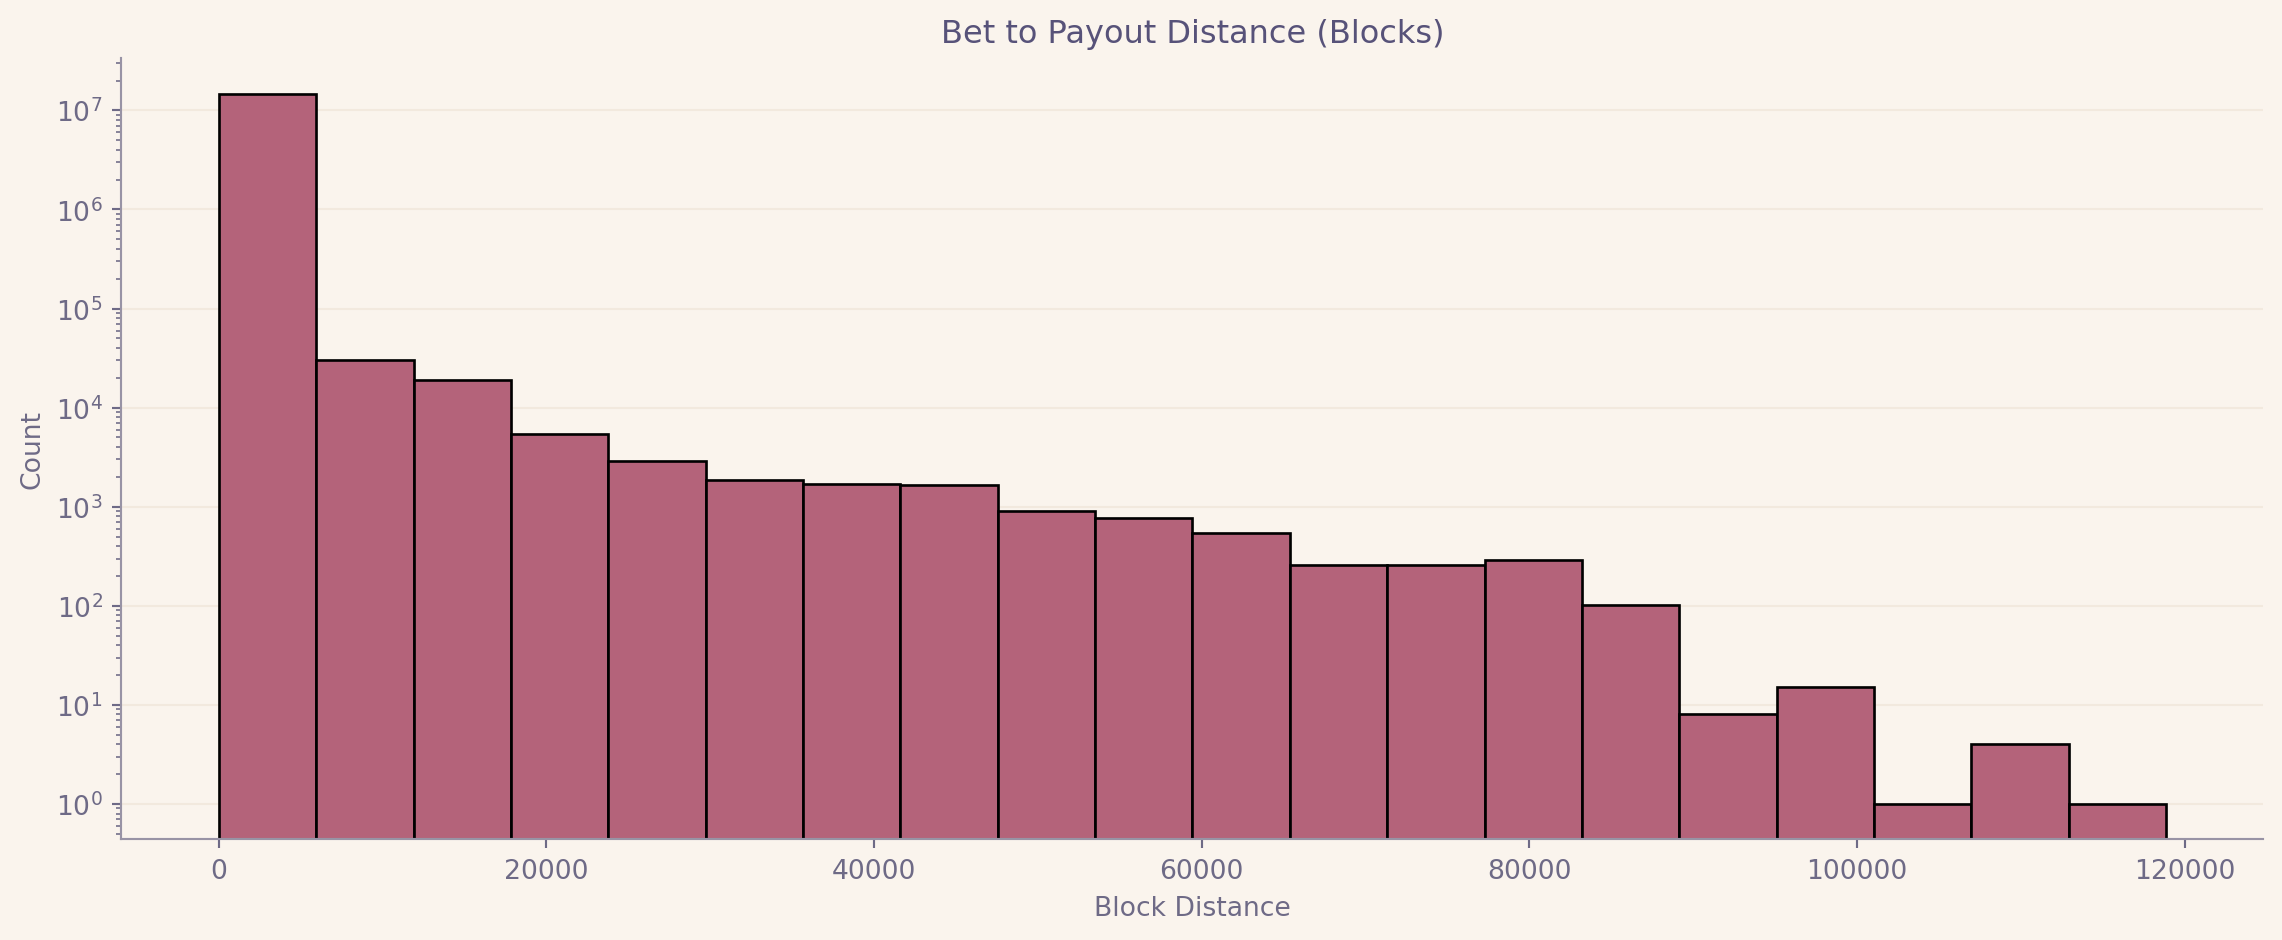

<Figure size 672x480 with 0 Axes>

In [8]:
from src.plotting.plots import plot_payout_distance_distribution
from src.data_loading.data_loader import read_parquet
import pandas

transactions = read_parquet("transactions", columns=["transaction_id", "transaction_block_id", "input_transaction_id", "is_satoshi_bet", "input_transaction_position", "output_position"])
# dropping transactions which don't have an input (which have not been spent yet)
transactions = transactions.dropna()

satoshi_payouts = pandas.merge(
    transactions[transactions["is_satoshi_bet"]],
    transactions,
    left_on=["input_transaction_id", "input_transaction_position"],
    right_on=["transaction_id", "output_position"]
)

block_delta = satoshi_payouts["transaction_block_id_x"] - satoshi_payouts["transaction_block_id_y"]

plot_payout_distance_distribution(block_delta)

In [9]:
from src.data_loading.satoshi_dices_info import k_most_popular_dices, address_hash, name

popular_dices = [name(address_hash(dice)) for dice in k_most_popular_dices(3)]

print(popular_dices)

['lessthan 32000', 'lessthan 32768', 'lessthan 48000']


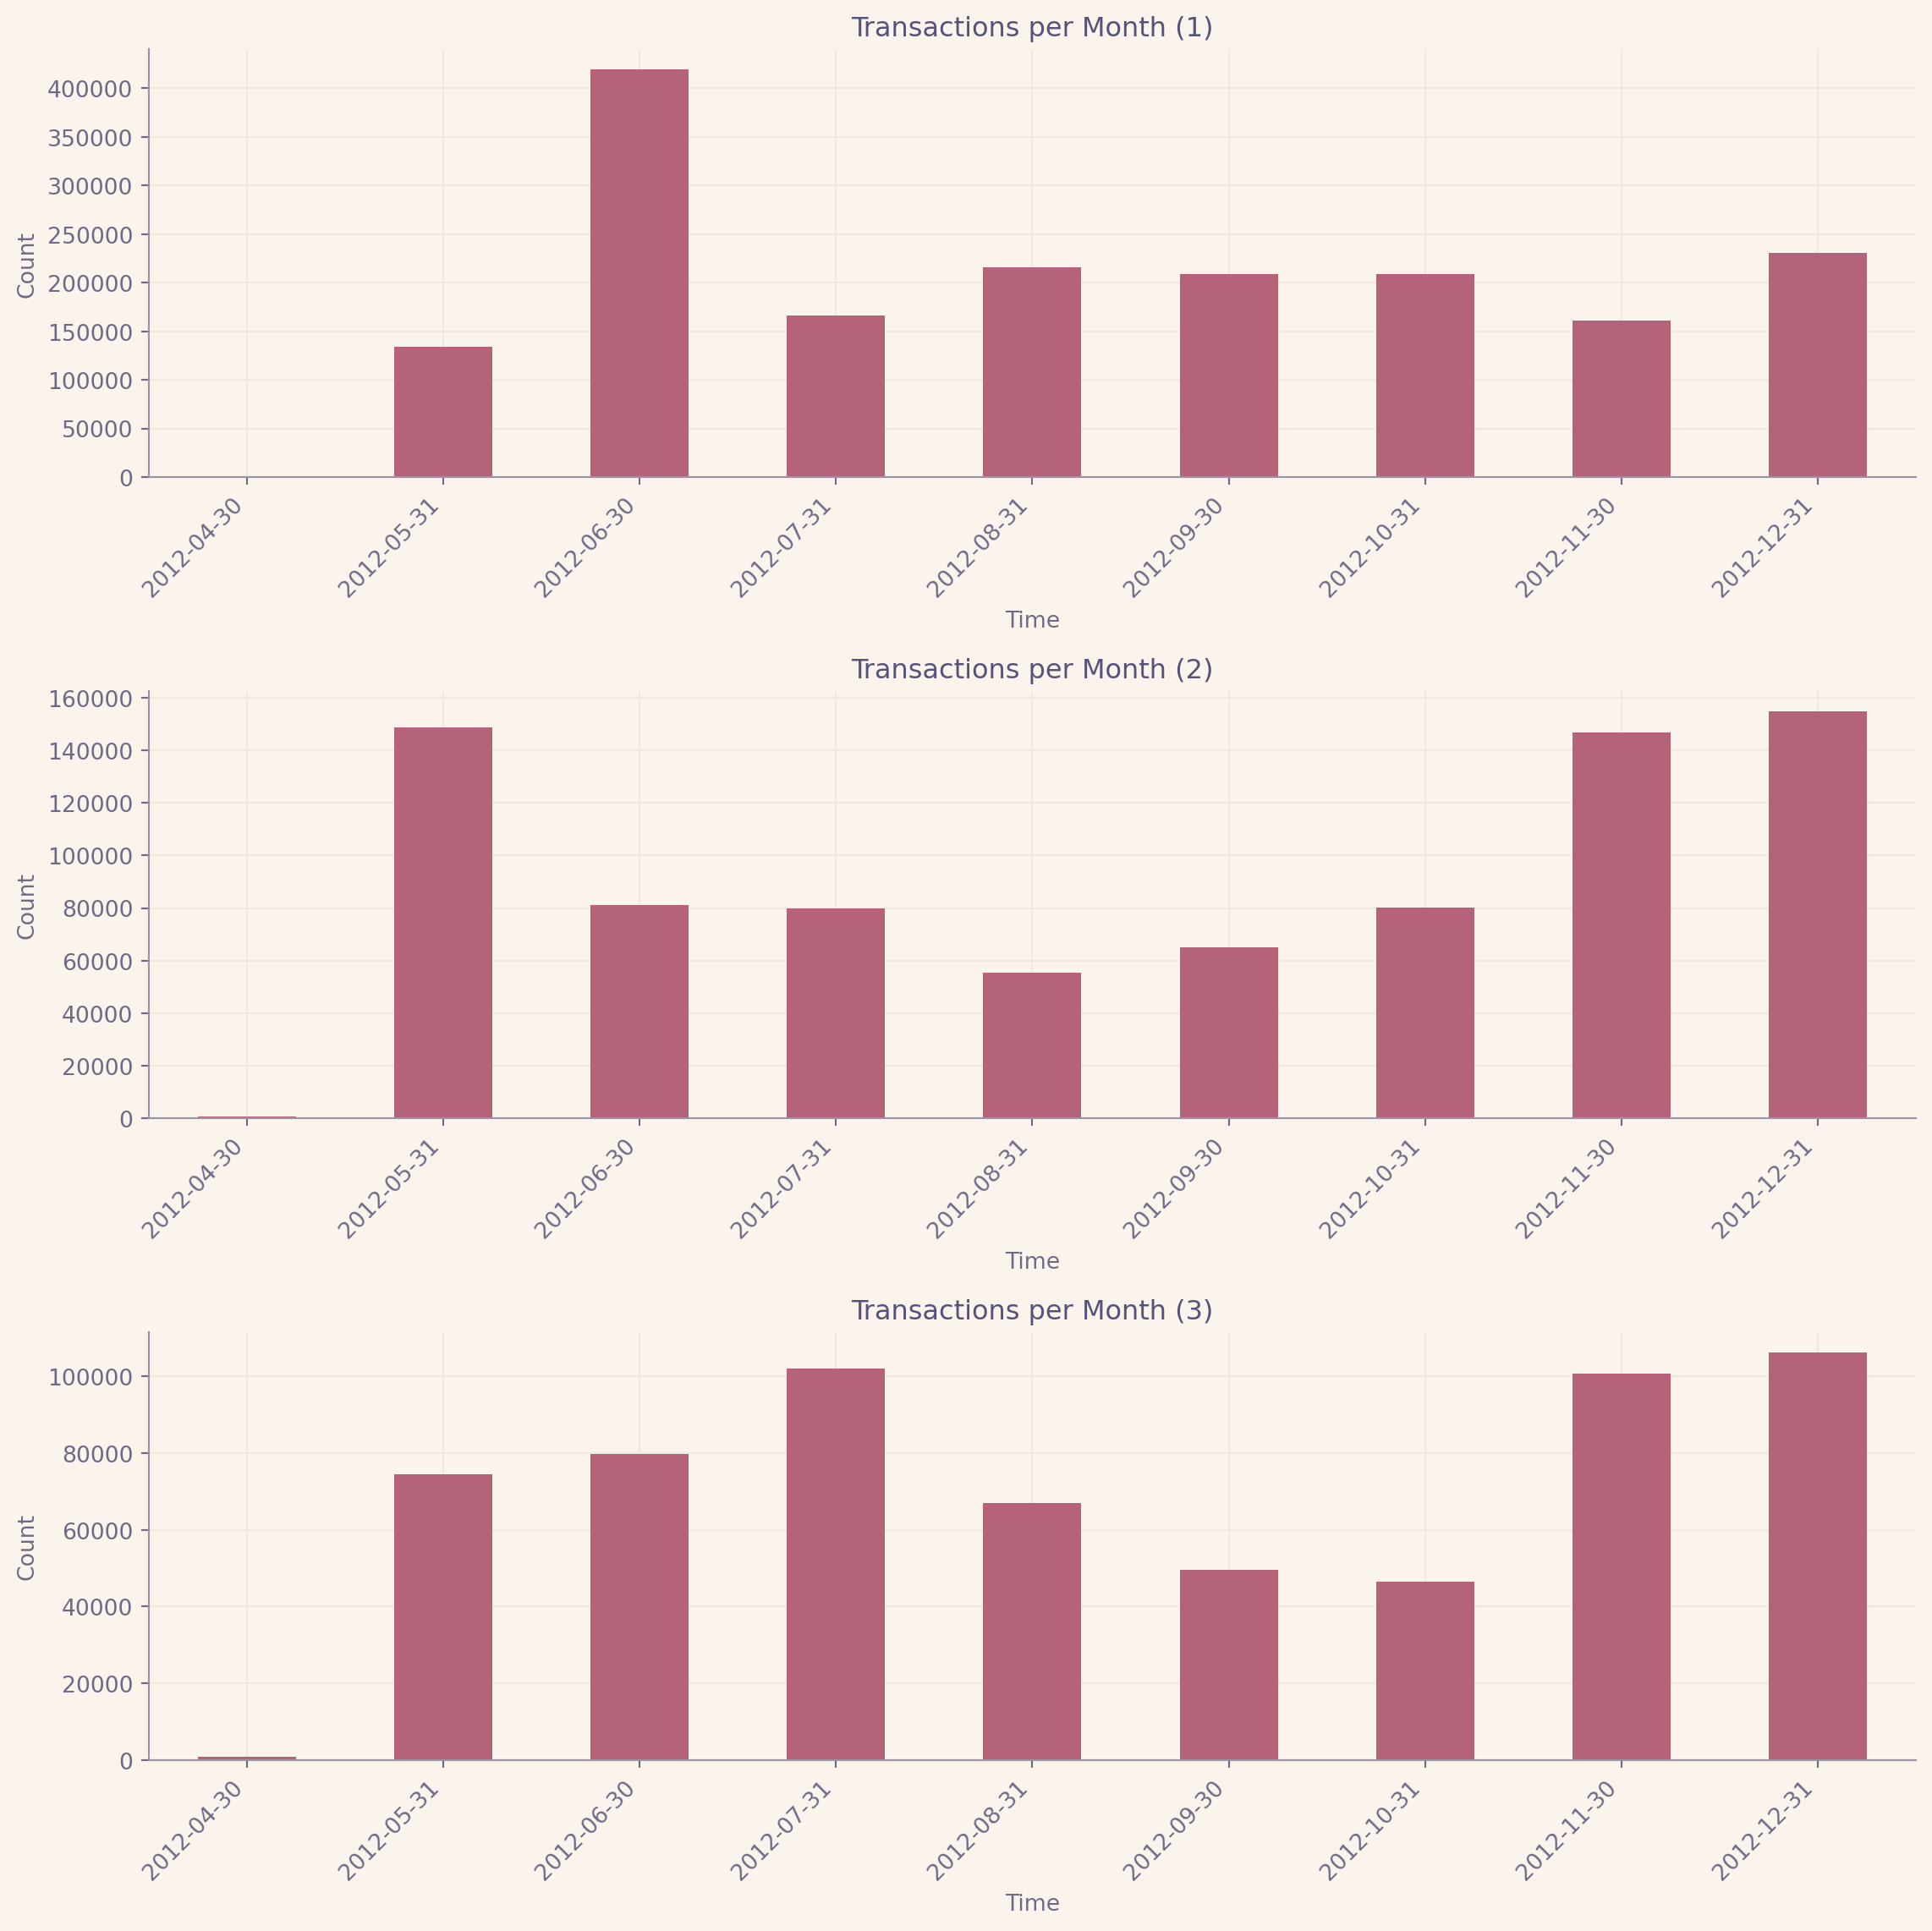

<Figure size 672x480 with 0 Axes>

In [10]:
import pandas
from src.data_loading.data_loader import read_parquet
from src.plotting.plots import plot_time_distribution
from src.plotting.plot_map_popular import plot_map_popular

transactions = read_parquet("transactions")
satoshi_bets = transactions[transactions["is_satoshi_bet"]]
satoshi_bets.drop_duplicates(subset="transaction_id")

def temporal_distribution(bets: pandas.DataFrame, time_step = "1ME"):
    return bets.resample(time_step, on="timestamp").size()

plot_map_popular(
    amount_popular_dices=3,
    bets_dataframe=satoshi_bets,
    map_function=temporal_distribution,
    plot_function=plot_time_distribution
)

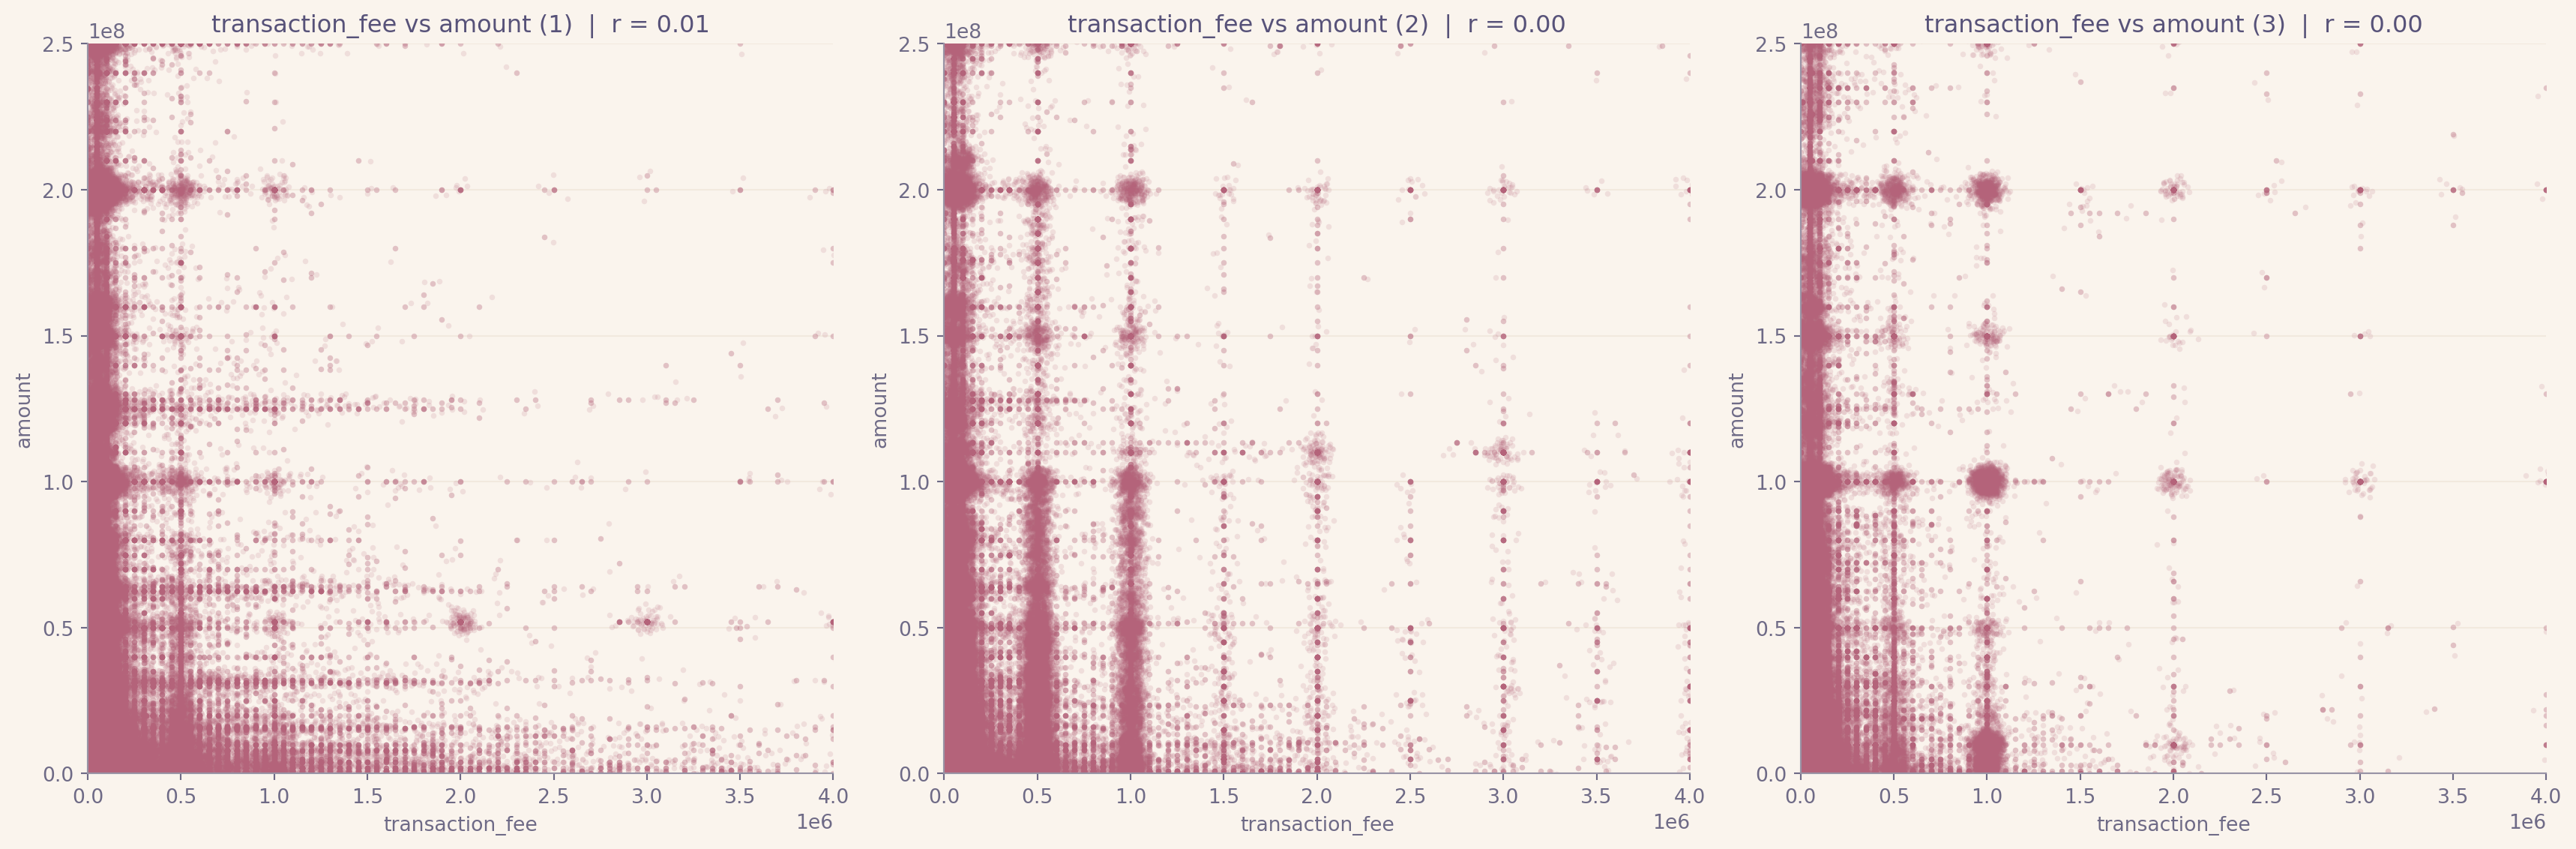

<Figure size 672x480 with 0 Axes>

In [11]:
from src.data_loading.data_loader import read_parquet
from src.plotting.plots import plot_bet_correlation
from src.plotting.plot_map_popular import plot_map_popular

transactions = read_parquet("transactions")
satoshi_bets = transactions[transactions["is_satoshi_bet"]]

satoshi_bets = satoshi_bets.drop_duplicates(subset=["transaction_id", "output_position"])

def identity(x):
    return x

plot_map_popular(
    amount_popular_dices=3,
    bets_dataframe=satoshi_bets,
    map_function=identity,
    plot_function=plot_bet_correlation
)

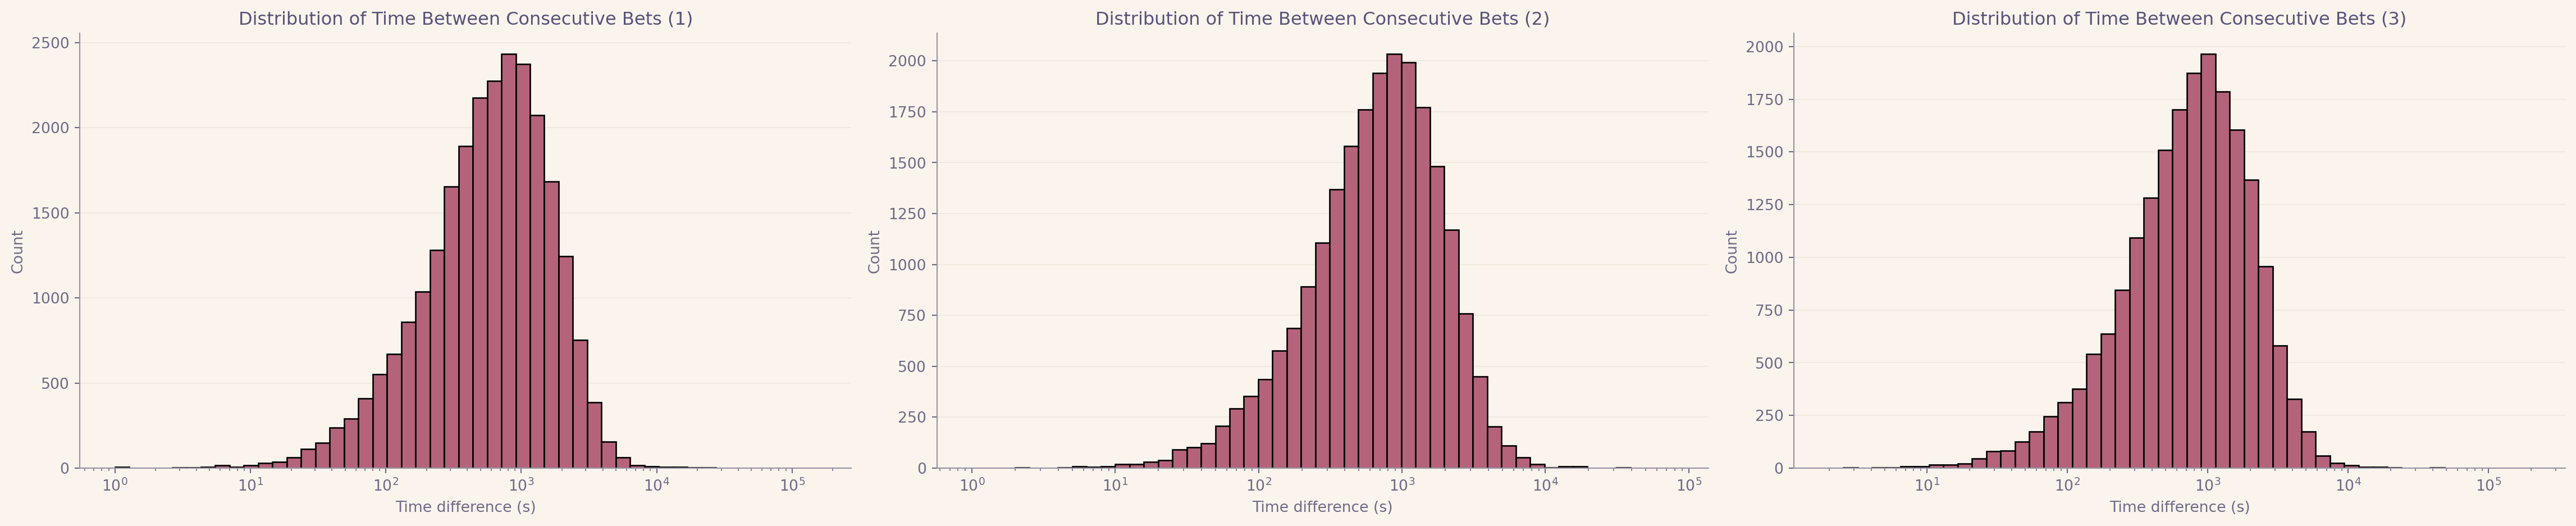

<Figure size 672x480 with 0 Axes>

In [12]:
import pandas
from src.data_loading.data_loader import read_parquet
from src.plotting.plots import plot_bet_distance
from src.plotting.plot_map_popular import plot_map_popular

transactions = read_parquet("transactions")
satoshi_bets = transactions[transactions["is_satoshi_bet"]]
satoshi_bets = satoshi_bets.drop_duplicates(subset="transaction_id")

def bet_distance(dataframe: pandas.DataFrame):
    return dataframe.sort_values("transaction_block_id")["timestamp"].diff().dt.total_seconds()

plot_map_popular(
    amount_popular_dices=3,
    bets_dataframe=satoshi_bets,
    map_function=bet_distance,
    plot_function=plot_bet_distance
)

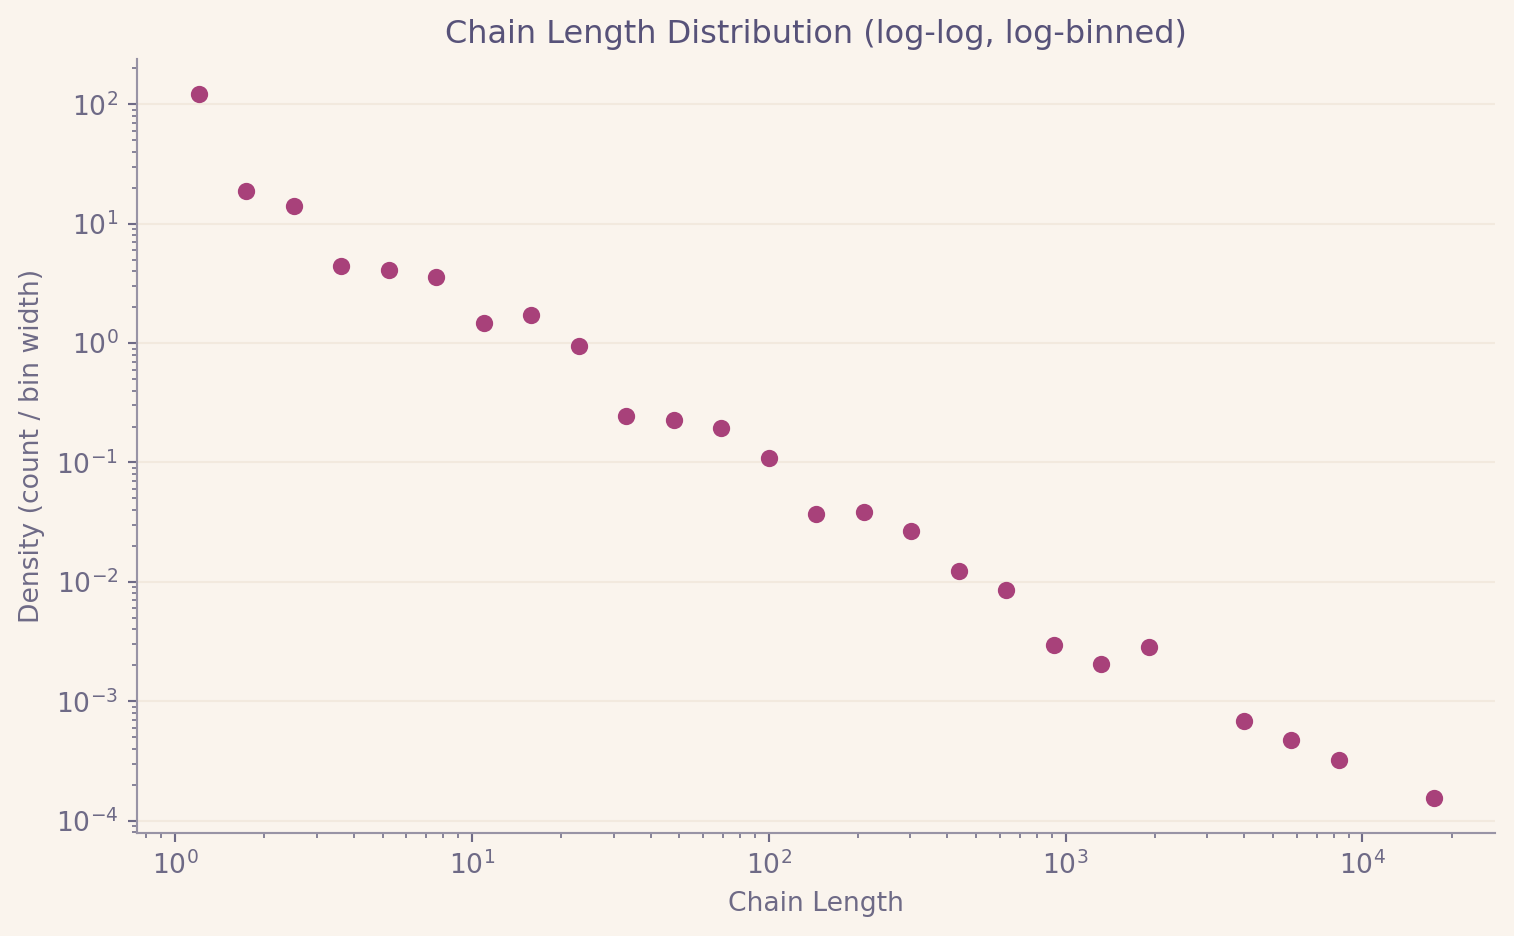

<Figure size 672x480 with 0 Axes>

In [13]:
import pandas
import networkx
from src.data_loading.satoshi_dices_info import k_most_popular_dices
from src.plotting.plots import plot_chain_length_distribution
from src.data_loading.data_loader import read_parquet
from src.analysis2.bet_chains_functions import simple_bets, transaction_connections, edges_attribute, save_to_csv

transactions = read_parquet(
    "transactions",
    columns=["transaction_id", "output_position", "input_transaction_id", "input_transaction_position", "output_address_id", "is_satoshi_bet"]
)

simple_bet_transactions = simple_bets(transactions)

simple_bet_connections = transaction_connections(simple_bet_transactions)

most_popular_dice_id = k_most_popular_dices(1)[0]
popular_simple_bets_connections = simple_bet_connections[simple_bet_connections["input_address"] == most_popular_dice_id]

G = networkx.from_pandas_edgelist(
    popular_simple_bets_connections,
    source="input_id",
    target="output_id",
    edge_attr=["output_address"],
    create_using=networkx.DiGraph,
)

paths_nodes = [edges_attribute(G, component, "output_address") for component in networkx.weakly_connected_components(G)]
paths_lengths = [len(nodes) for nodes in paths_nodes]

length_distribution = pandas.Series(paths_lengths).value_counts().sort_index()

save_to_csv('./data/processed/simple_bet_chain_nodes.csv', paths_nodes)
plot_chain_length_distribution(length_distribution)

In [14]:
from src.data_loading.address_to_wallet_mapping import get_wallet, load_cache, load_driver
import csv
from itertools import islice
import uuid
from collections import Counter
import pandas

def read_first_k_chains(filepath: str, k: int) -> list[list[str]]:
    with open(filepath, newline="", encoding="utf-8") as f:
        return list(islice(csv.reader(f), k))


cache = load_cache()
driver = load_driver()

bitcoin_address_chains = read_first_k_chains("./data/processed/simple_bet_chain_nodes.csv", 10)

wallet_address_chains = [[get_wallet(cache, driver, bitcoin_address) for bitcoin_address in chain] for chain in bitcoin_address_chains]

def summarize_chain(bitcoin_addresses: list[str], wallet_addresses: list[str]) -> dict:

    dominant_wallet_address, dominant_wallet_count = Counter(wallet_addresses).most_common(1)[0]

    return {
        "id": uuid.uuid4(),
        "chain_length": len(bitcoin_addresses),
        "unique_addresses": len(set(bitcoin_addresses)),
        "unique_wallets": len(set(wallet_addresses)),
        "dominant_wallet": dominant_wallet_address,
        "dominant_wallet_percentage": dominant_wallet_count / len(wallet_addresses) * 100,
    }

chains_data = [summarize_chain(bitcoin_addresses, wallet_addresses)
          for bitcoin_addresses, wallet_addresses in zip(bitcoin_address_chains, wallet_address_chains)]

chains_data = pandas.DataFrame(chains_data)

chains_data.to_csv("./outputs/deanonymized_chains.csv", index=None)

print(chains_data)

                                     id  chain_length  unique_addresses  \
0  df94ce40-e700-4bbd-92f2-67e3b70b394d           716               716   
1  d8792eba-9245-4f77-b102-0173aebecb1a           441               441   
2  4f7bfda4-41e3-452e-ae69-4219064a8657           351               351   
3  363ba56a-d2a0-4f9e-b903-735e0aab816a           292               292   
4  2d74b9de-119f-4da8-b27e-0c5a81bf07bb           272               272   
5  643493d7-cf69-4162-9f97-ce3b59420f8a           245               245   
6  7601c213-5eb9-47b3-a947-0055ef24352d           242               242   
7  84ff0e00-d896-4316-a96f-ea459447169f           234               234   
8  9037d6af-bfff-4d09-a9e7-00a9ecacddd2           232               232   
9  62593ef4-e3f9-4c16-9460-21714fd4fc08           228               228   

   unique_wallets dominant_wallet  dominant_wallet_percentage  
0              76    [0025d633f8]                   50.139665  
1               1    [00002c4379]             